In [1]:
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

import specula
specula.init(0)

from scipy.ndimage import rotate
from specula.data_objects.ifunc import IFunc
from specula.data_objects.ifunc_inv import IFuncInv

2026-08-17 09:58:42,861 [INFO]: [specula]: Cupy import successfull. Installed version is: 13.3.0
2026-08-17 09:58:42,940 [INFO]: [specula]: Default device is GPU number 0


In [2]:
import matplotlib as mpl
from cycler import cycler

cmap = mpl.colormaps['hot'] # 1. Choose your colormap (e.g., 'hot', 'jet', 'turbo')
colors = cmap(np.linspace(0.0, 1.0, 7)) # 2. Extract a set of colors from it (e.g., 6 distinct colors across the map)
plt.rcParams['axes.prop_cycle'] = cycler(color=colors) # 3. Apply it to the default line cycle
plt.rcParams['image.cmap'] = 'hot' # 4. Change the default colormap for images/scatter plots
plt.rcParams.update({
    "text.usetex": True, # Use LaTeX to write all text
    "font.family": "serif", # Use a serif font
    "font.serif": ["Computer Modern Roman"] # Specifically use the classic LaTeX font
})
plt.rcParams['image.origin'] = 'lower'

In [3]:
def show2d_slopes(slopes,npix=120,normalize:bool=False,title='',vmin=None,vmax=None,show=True,ppath='pyr_pupdata_40x40',newfig:bool=False):
    if normalize:
        slopes -= np.mean(slopes)
        slopes_rms = np.std(slopes)
        slopes /= slopes_rms

    filepath=f'/raid1/mmenessini/calibration/SOUL/KLv30dx/pupils/{ppath}.fits'
    pup_hdu = fits.open(filepath)
    pup_ids = pup_hdu[1].data
    fimg = np.zeros(npix**2)
    np.put(fimg, pup_ids[:,0], slopes[:len(slopes)//2])
    np.put(fimg, pup_ids[:,1], slopes[len(slopes)//2:])
    f2d = fimg.reshape([npix,npix])

    if vmin is None:
        vmin = np.min(f2d)
    if vmax is None:
        vmax = np.max(f2d)
    
    if show:
        if newfig:
            plt.figure()
        plt.imshow(np.ma.masked_array(f2d,mask=np.abs(f2d)==0),origin='lower',cmap='RdBu',vmin=vmin,vmax=vmax)
        plt.ylim([12,60])
        plt.xlim([12,108])
        plt.axis('off')
        plt.title(title)
        plt.colorbar(shrink=0.5)
    return f2d

In [4]:
pupids = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/pupils/pup_ids.fits')
pyr_masks = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/pupils/lbt_pupmask_shift.fits').astype(bool)

rec = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/data/Rec_20251120_085351.fits')
refim = np.linalg.pinv(rec)

def show_im_slopes_idx(idx:int,im=refim):
    half_mask = pyr_masks[:60,:120].astype(bool)
    img = np.zeros(np.size(half_mask))
    img[half_mask.flatten()] = im[pupids,idx]
    img = img.reshape([60,120])
    plt.imshow(np.ma.masked_array(img,mask=img==0),origin='lower',cmap='RdBu')
    plt.colorbar(shrink=0.5)
    plt.ylim([12,60])
    plt.xlim([12,120-12-1])
    plt.axis('off')

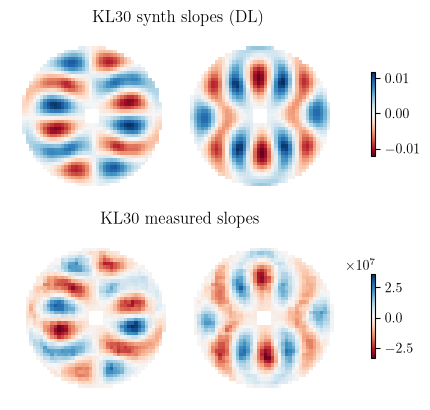

In [10]:
idx = 30
plt.figure()
plt.subplot(2,1,2)
show_im_slopes_idx(idx=idx)
plt.title(f'KL{idx} measured slopes')

aux = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/im/pyr3.0_40x40_lbti_synim.fits')
synim = aux.copy()
synim[:2512//2,:] = aux[2512//2:,:]
synim[2512//2:,:] = aux[:2512//2,:]*-1
plt.subplot(2,1,1)
f2dopt=show2d_slopes(synim[:,idx],ppath='lbt_pupdata',title=f'KL{idx} synth slopes (DL)')

In [6]:
ifunc = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/ifunc/asm_v30dx_lbti_ifunc_shift.fits')
# klinv = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/ifunc/asm_v30dx_lbti_ifunc_shift_inv.fits')
# ifunc = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/ifunc/asm_v30dx_ifunc.fits')
m2c = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/m2c/asm_v30dx_m2c.fits')
kl = (ifunc @ m2c)
# print(m2c.shape,ifunc.shape)
# data = readsav('/raid1/mmenessini/LBTData/KLv30dx/phase_matrix.sav')
# m2c_full = data['klm2c']
# act_ids = np.sum(abs(m2c_full),axis=1)>0
# c2m = np.linalg.pinv(m2c_full[act_ids,:ifunc.shape[1]])
# kl = np.linalg.pinv(c2m @ ifunc.T)
# kl = np.linalg.pinv(klinv)
lbtpup = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/pupilstop/asm_v30dx_197pixels.fits')
lbtpup_crop = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/pupilstop/asm_v30dx_197pixels_optshift.fits')

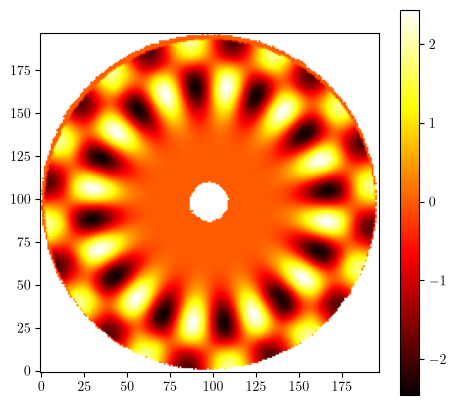

In [7]:
img = np.zeros(lbtpup.shape)
img[lbtpup.astype(bool)] = kl[:,100]
img = np.ma.masked_array(img,mask=(1-lbtpup_crop).astype(bool))


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(img)
plt.colorbar()

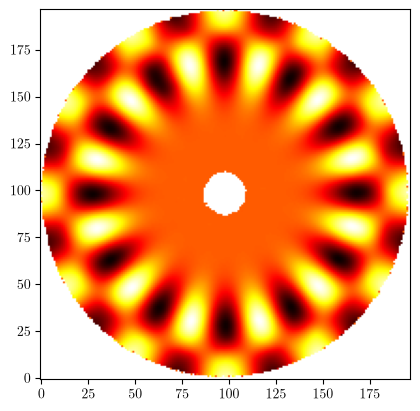

In [8]:
frames = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/scratch_synim/dm_ef.fits')[:,1,:,:]
amps = fits.getdata('/raid1/mmenessini/results/SOUL/KLv30dx/scratch_synim/dm_ef.fits')[:,0,:,:]

plt.figure()
plt.imshow(np.ma.masked_array(frames[100*2],mask=(1-lbtpup_crop).astype(bool)),origin='lower')

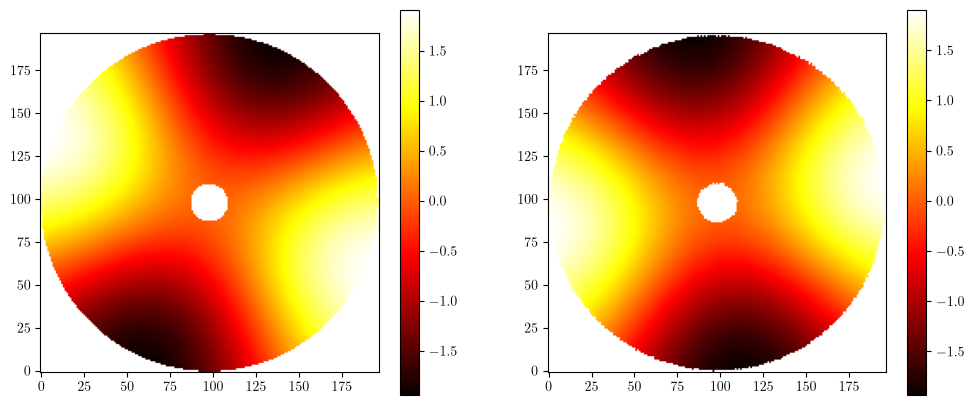

In [9]:
from skimage.transform import AffineTransform,warp

ifunc = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/ifunc/asm_v30dx_ifunc.fits')
m2c = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/m2c/asm_v30dx_m2c.fits')
kl = (ifunc @ m2c)
lbtpup = fits.getdata('/raid1/mmenessini/calibration/SOUL/KLv30dx/pupilstop/asm_v30dx_197pixels.fits')

img = np.zeros(lbtpup.shape)
img[lbtpup.astype(bool)] = kl[:,4]

def rotate_and_shift(img,rot=0,shfX=0,shfY=0,mag=1.0,shear=0):
    center_y, center_x = img.shape[0]/2.0, img.shape[1]/2.0
    shift_to_origin = AffineTransform(translation=(-center_x, -center_y))
    shear_and_scale = AffineTransform(shear=shear, rotation=rot, scale=mag)
    shift_to_center = AffineTransform(translation=(center_x+shfX, center_y+shfY))
    trf = shift_to_origin + shear_and_scale + shift_to_center
    warp_img = warp(img, inverse_map=trf.inverse)
    return warp_img

rot_img = rotate_and_shift(img,rot=np.pi/6)
rot_mask = rotate_and_shift(lbtpup.astype(float),rot=np.pi/6)

plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.imshow(np.ma.masked_array(img,mask=(1-lbtpup).astype(bool)))
plt.colorbar()
plt.subplot(1,2,2)
plt.imshow(np.ma.masked_array(rot_img,mask=(1-rot_mask).astype(bool)))
plt.colorbar()